# Load Preprocessed Data

In [8]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest


# File name
PREPROCESSED_NN_DATA_FILE_NAME = "loan_data_preprocessed_nn.csv"
PREPROCESSED_XGB_DATA_FILE_NAME = "loan_data_preprocessed_xgb.csv"

PROJECT_ROOT = Path("..")
PREPROCESSED_NN_DATA_FILE_PATH = PROJECT_ROOT / "data" / "pre_processed" / PREPROCESSED_NN_DATA_FILE_NAME
PREPROCESSED_XGB_DATA_FILE_PATH = PROJECT_ROOT / "data" / "pre_processed" / PREPROCESSED_XGB_DATA_FILE_NAME

OUTPUT_DIR = PROJECT_ROOT / "data" / "pre_processed"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Preprocessed NN data path:", PREPROCESSED_NN_DATA_FILE_PATH)
print("Preprocessed XGB data path:", PREPROCESSED_XGB_DATA_FILE_PATH)
print("Output folder:", OUTPUT_DIR)

nn_df = pd.read_csv(PREPROCESSED_NN_DATA_FILE_PATH)
xgb_df = pd.read_csv(PREPROCESSED_XGB_DATA_FILE_PATH)
print(nn_df.shape)
print(xgb_df.shape)
nn_df.head()
xgb_df.head()

PROJECT_ROOT: ..
Preprocessed NN data path: ..\data\pre_processed\loan_data_preprocessed_nn.csv
Preprocessed XGB data path: ..\data\pre_processed\loan_data_preprocessed_xgb.csv
Output folder: ..\data\pre_processed
(45000, 27)
(45000, 27)


,num__person_age,num__person_income,num__person_emp_exp,num__loan_amnt,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,num__credit_score,cat__person_gender_female,cat__person_gender_male,...,cat__person_home_ownership_OWN,cat__person_home_ownership_RENT,cat__loan_intent_DEBTCONSOLIDATION,cat__loan_intent_EDUCATION,cat__loan_intent_HOMEIMPROVEMENT,cat__loan_intent_MEDICAL,cat__loan_intent_PERSONAL,cat__loan_intent_VENTURE,bin__previous_loan_defaults_on_file,loan_status
0,22.0,71948.0,0.0,35000.0,16.02,0.49,3.0,561.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,21.0,12282.0,0.0,1000.0,11.14,0.08,2.0,504.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
2,25.0,12438.0,3.0,5500.0,12.87,0.44,3.0,635.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
3,23.0,79753.0,0.0,35000.0,15.23,0.44,2.0,675.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
4,24.0,66135.0,1.0,35000.0,14.27,0.53,4.0,586.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1


# Apply Isolation Forest on Preprocessed NN Data

In [9]:
# Only consider numerical columns for Isolation Forest
nn_features = nn_df.select_dtypes(include="number").columns.tolist()
nn_X = nn_df[nn_features].values

nn_isolation_forest_model = IsolationForest(n_estimators=100, random_state=42)
nn_isolation_forest_model.fit(nn_X)

nn_y_predictions = nn_isolation_forest_model.predict(nn_X)
nn_anomaly_scores = nn_isolation_forest_model.decision_function(nn_X)

nn_df["outlier_prediction"] = nn_y_predictions
nn_df["anomaly_score"] = nn_anomaly_scores

print(f"Total samples for preprocessed NN data: {len(nn_y_predictions)}")
print(f"Number of outliers for preprocessed NN data: {(nn_y_predictions == -1).sum()}")

Total samples for preprocessed NN data: 45000
Number of outliers for preprocessed NN data: 15743


# Anomaly Score Distribution of Preprocessed NN Data

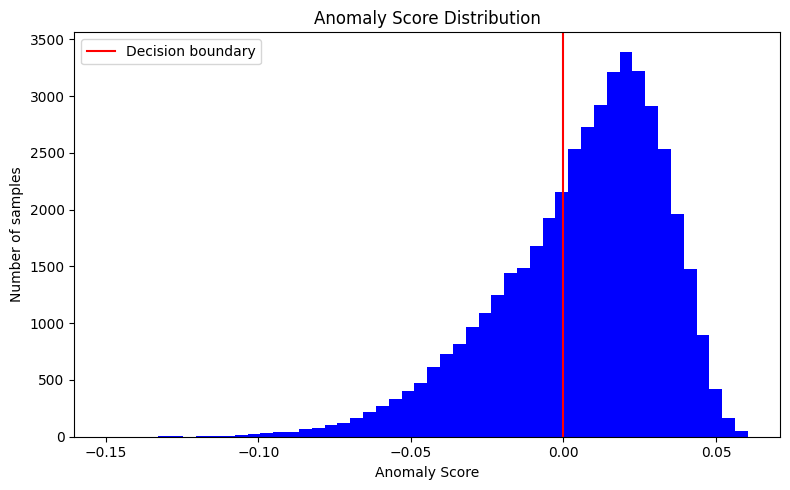

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(nn_anomaly_scores, bins=50, color="blue")
# outlier is less than 0, normal is greater than 0
plt.axvline(0, color="red", linestyle="-", label="Decision boundary")
plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of samples")
plt.legend()

plt.tight_layout()
plt.show()

# Apply Isolation Forest on Preprocessed XGB Data

In [11]:
# Only consider numerical columns for Isolation Forest
xgb_features = xgb_df.select_dtypes(include="number").columns.tolist()
xgb_X = xgb_df[xgb_features].values

xgb_isolation_forest_model = IsolationForest(n_estimators=100, random_state=42)
xgb_isolation_forest_model.fit(xgb_X)

xgb_y_predictions = xgb_isolation_forest_model.predict(xgb_X)
xgb_anomaly_scores = xgb_isolation_forest_model.decision_function(xgb_X)

xgb_df["outlier_prediction"] = xgb_y_predictions
xgb_df["anomaly_score"] = xgb_anomaly_scores

print(f"Total samples for preprocessed XGB data: {len(xgb_y_predictions)}")
print(f"Number of outliers for preprocessed XGB data: {(xgb_y_predictions == -1).sum()}")

Total samples for preprocessed XGB data: 45000
Number of outliers for preprocessed XGB data: 15743


# Anomaly Score Distribution of Preprocessed XGB Data

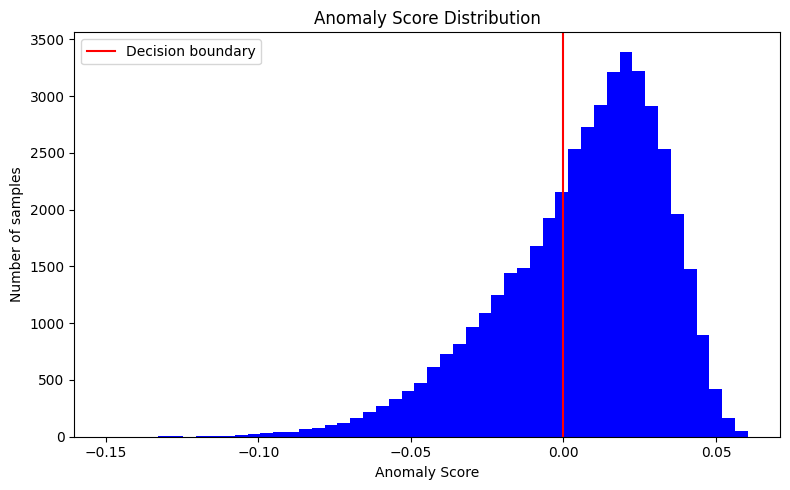

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(xgb_anomaly_scores, bins=50, color="blue")
# outlier is less than 0, normal is greater than 0
plt.axvline(0, color="red", linestyle="-", label="Decision boundary")
plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of samples")
plt.legend()

plt.tight_layout()
plt.show()

# Remove Outliers

In [13]:
nn_outlier_indices = nn_df.index[nn_df["outlier_prediction"] == -1]
xgb_outlier_indices = xgb_df.index[xgb_df["outlier_prediction"] == -1]

nn_df = nn_df.drop(index=nn_outlier_indices).drop(columns=["outlier_prediction", "anomaly_score"]).reset_index(drop=True)
xgb_df = xgb_df.drop(index=xgb_outlier_indices).drop(columns=["outlier_prediction", "anomaly_score"]).reset_index(drop=True)

print(nn_df.shape)
print(f"Number of rows removed for preprocessed NN data: {len(nn_outlier_indices)}")
print(xgb_df.shape)
print(f"Number of rows removed for preprocessed XGB data: {len(xgb_outlier_indices)}")

(29257, 27)
Number of rows removed for preprocessed NN data: 15743
(29257, 27)
Number of rows removed for preprocessed XGB data: 15743


# Save trimmed preprocessed CSV files

In [14]:
nn_output_path = OUTPUT_DIR / "loan_data_trimmed_preprocessed_nn.csv"
xgb_output_path = OUTPUT_DIR / "loan_data_trimmed_preprocessed_xgb.csv"

nn_df.to_csv(nn_output_path, index=False)
xgb_df.to_csv(xgb_output_path, index=False)

print("Saved Neural Network data to:", nn_output_path)
print("Saved XGBoost data to:", xgb_output_path)

Saved Neural Network data to: ..\data\pre_processed\loan_data_trimmed_preprocessed_nn.csv
Saved XGBoost data to: ..\data\pre_processed\loan_data_trimmed_preprocessed_xgb.csv
